# Model Evaluation Metrics

In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Regression Model Metrics

##### As Regression Models predict the continuous values so efficiency is found with difference of predicted to real values

In [2]:
X = np.linspace(0, 100, 100)
print(X[:5])
y = 3 * X + 10 + np.random.normal(0, 5, size=X.shape) # add some noise to the data
print(y[:5])

y_pred = 3 * X + 12
print(y_pred[:5])

[0.         1.01010101 2.02020202 3.03030303 4.04040404]
[17.19335297  9.15707279 18.15364705 19.71480054 16.1709362 ]
[12.         15.03030303 18.06060606 21.09090909 24.12121212]


### RMSE/MSE (Root Mean / Mean Squared Error)

MSE : It is Average squared difference between predicted and actual values.
$$
mse = \frac {1}{n}\sum_{i=1}^{n} ((y_a)_i - (y_p)_i)^2
$$
RMSE: It is Square root of MSE, interpretable in the same units as the target variable
$$
rmse = \sqrt {\frac {1}{n} \sum_{i=1}^{n} ((y_a)_i - (y_p)_i)^2}
$$


##### (y_a)_i: the i th actual value from the data  
##### (y_p)_i: the i th predicted value from the model

In [3]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error     : {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Squared Error     : 24.52
Root Mean Squared Error: 4.95


### MAE (Mean Absolute Error)

MAE : It is Average absolute difference between predicted and actual values.
$$
mae = \frac {1}{n}\sum_{i=1}^{n} | (y_a)_i - (y_p)_i |
$$

In [4]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, y_pred)
print(f'Mean Absolute Error : {mae:.2f}')

Mean Absolute Error : 4.07


### R^2 (Coefficient of Determination)

- It is Proportion of variance explained by the model.
- Higher values indicate better fit
$$
R^2 = 1 - \frac {RSS}{TSS}
$$
#### Where
#### RSS - Residual Sum of Squares
$$
RSS = \sum_{i=1}^{n} ((y_a)_i - (y_p)_i)^2
$$
#### TSS - Total Sum of Squares
$$
TSS = \sum_{i=1}^{n} ((y_a)_i - y_m)^2
$$
y_m : mean of observed values

In [5]:
from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
print(f'R² Score : {r2:.4f}')

R² Score : 0.9968


### Uses
- **RMSE** : During training  
- **MSE / MAE** :  
  - For reporting errors  
  - Depending on sensitivity to outliers  
- **R²** : For model comparison / explanatory power

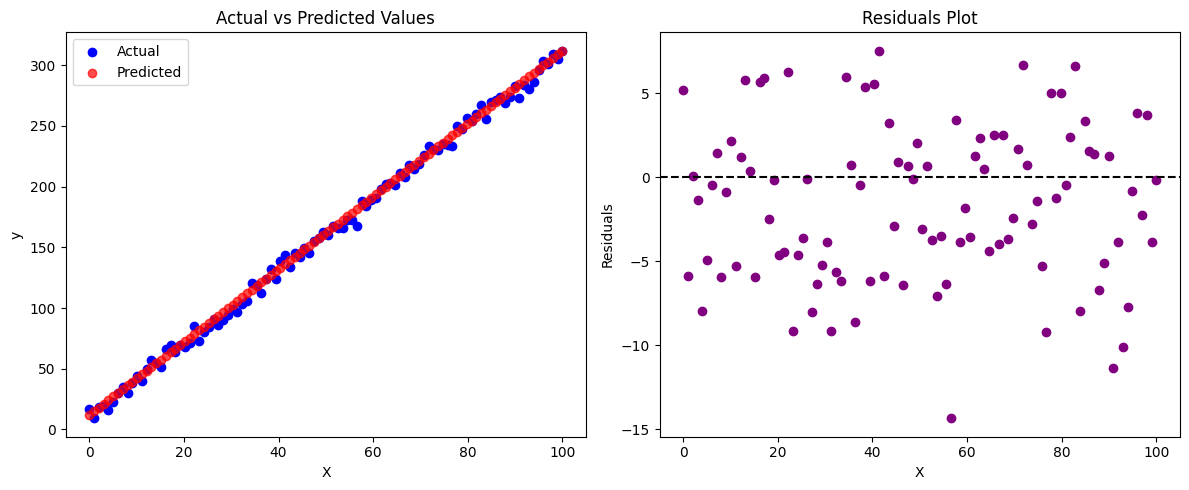

In [6]:
plt.figure(figsize=(12,5))

# Scatter plot of actual vs predicted
plt.subplot(1,2,1)
plt.scatter(X, y, label="Actual", color="blue")
plt.scatter(X, y_pred, label="Predicted", color="red", alpha=0.7)
plt.title("Actual vs Predicted Values")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

# Residuals plot
residuals = y - y_pred
plt.subplot(1,2,2)
plt.scatter(X, residuals, color="purple")
plt.axhline(y=0, color="black", linestyle="--")
plt.title("Residuals Plot")
plt.xlabel("X")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

## Classification Model Metrics

##### As Classification Model Predicts the Categories as **Discrete values** so efficiency is measured on count of values

In [7]:
y_true_bin = np.random.choice([0, 1], size=1000, p=[0.6, 0.4]) # 0 with 60% probability, 1 with 40% probability
print(y_true_bin[:10])

y_pred_bin = y_true_bin.copy()
noise_indices = np.random.choice(range(1000), size=200, replace=False) # introduce 200 errors
y_pred_bin[noise_indices] = 1 - y_pred_bin[noise_indices] # flip labels for errors
print(y_pred_bin[:10])

[0 0 0 1 1 0 0 0 1 0]
[1 0 0 1 1 0 1 0 1 1]


In [8]:
y_true_class = np.random.choice([0, 1, 2, 3], size=1000, p=[0.4, 0.25, 0.25, 0.1])
print(y_true_class[:10])

y_pred_class = y_true_class.copy()
noise_indices = np.random.choice(range(1000), size=300, replace=False) # introduce 300 errors
y_pred_class[noise_indices] = np.random.choice([0, 1, 2, 3], size=300) # assign random class for errors
print(y_pred_class[:10])

[2 0 0 1 0 3 0 0 0 0]
[2 0 0 1 0 0 0 0 0 0]


### Confusion Matrix

- A confusion matrix (also called an error matrix) is a square table used in classification problems.
- Rows represent the actual classes, while columns represent the predicted classes (or vice versa).
- The diagonal entries show correct predictions, while off-diagonal entries show misclassifications


| Actual \ Predicted | Positive | Negative |
|---------------------|----------|----------|
| **Positive**        | True Positive (TP)     | False Negative (FN)      |
| **Negative**        | False Positive (FP)      | True Negative  (TN)     |

##### Binary Classification

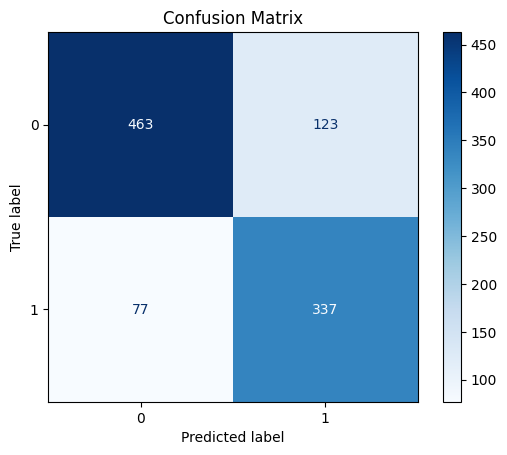

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_bin = confusion_matrix(y_true_bin, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["0", "1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

##### Multi Class Classification

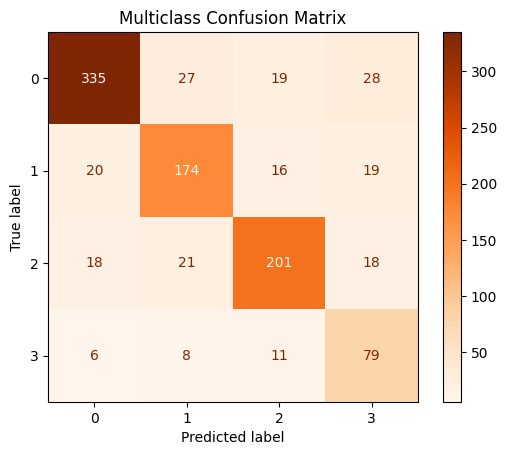

In [10]:
cm_multi = confusion_matrix(y_true_class, y_pred_class)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=["0", "1", "2", "3"])
disp_multi.plot(cmap=plt.cm.Oranges)
plt.title("Multiclass Confusion Matrix")
plt.show()

#### Accuracy

- Proportion of correct predictions.
- **Best when classes are balanced**
$$
accuracy = \frac {TP + TN}{Total}
$$
Total = TP + FN + FP + TN

##### Binary Classification

In [11]:
from sklearn.metrics import accuracy_score

accuracy_bin = accuracy_score(y_true_bin, y_pred_bin)
print(f'Accuracy : {accuracy_bin:.4f}')

Accuracy : 0.8000


##### Multi Class Classification

In [12]:
accuracy_multi = accuracy_score(y_true_class, y_pred_class)
print(f'Multiclass Accuracy : {accuracy_multi:.4f}')

Multiclass Accuracy : 0.7890


#### Precision

- Fraction of correctly predicted positives out of all true predicted.
- **Important when false positives are costly**
$$
precision = \frac {TP}{TP + TN}
$$
##### Example : Medical Diagnosis (as FP are need to be minimized)

##### Binary Classification

In [13]:
from sklearn.metrics import precision_score

precision_bin = precision_score(y_true_bin, y_pred_bin)
print(f'Precision : {precision_bin:.4f}')

Precision : 0.7326


##### Multi Class Classification

In [14]:
precision_multi = precision_score(y_true_class, y_pred_class, average='weighted')
print(f'Multiclass Precision : {precision_multi:.4f}')

Multiclass Precision : 0.8018


#### Recall

- Fraction of correctly predicted positives out of all actual positives.
- **Crucial when missing positives is costly**
$$
recall = \frac {TP}{TP + FN}
$$
##### Example : Fraud Detection 

##### Binary Classification

In [15]:
from sklearn.metrics import recall_score

recall_bin = recall_score(y_true_bin, y_pred_bin)
print(f'Recall : {recall_bin:.4f}')

Recall : 0.8140


##### Multi Class Classification

In [16]:
recall_multi = recall_score(y_true_class, y_pred_class, average='weighted')
print(f'Multiclass Recall : {recall_multi:.4f}')

Multiclass Recall : 0.7890


#### F1-Score (important metric for classification)

- Harmonic mean of precision and recall.
- **Useful for imbalanced datasets**
$$
F1 - Score = 2 \cdot \frac {precision \cdot recall}{precision + recall}
$$

| Domain            | Preferred F1 Variant(s)         | Preferred Range (Good → Excellent) | Why This Range Matters |
|-------------------|---------------------------------|------------------------------------|------------------------|
| Medical Analysis  | Macro F1 + Per-Class F1         | 0.70–0.80 (good), ≥0.85 (excellent) | Rare diseases must be detected reliably; high F1 ensures both precision (few false alarms) and recall (few missed cases). |
| Fraud Detection   | Per-Class F1 (fraud class) + Macro F1 | 0.60–0.75 (acceptable), ≥0.80 (strong) | Fraud is rare but costly; even moderate F1 is valuable, but higher scores mean fewer missed frauds and fewer false positives. |
| Customer Churn    | Weighted F1                     | 0.65–0.75 (good), ≥0.80 (excellent) | Reflects real-world distribution; weighted F1 balances majority (non-churn) with minority (churn) class performance. |

##### Binary Classification

In [17]:
from sklearn.metrics import f1_score

f1_bin = f1_score(y_true_bin, y_pred_bin)
print(f'F1 Score : {f1_bin:.4f}')

F1 Score : 0.7712


##### Multi Class Classification

In [18]:
f1_multi = f1_score(y_true_class, y_pred_class, average='weighted')
print(f'Multiclass F1 Score : {f1_multi:.4f}')

Multiclass F1 Score : 0.7930


### Classification Report

It's a detailed summary of a classification model’s performance showing precision, recall, F1-score, and support for each class.

**Support : Number of actual occurrences of each class in the dataset.**

In [19]:
from sklearn.metrics import classification_report

report_bin = classification_report(y_true_bin, y_pred_bin, target_names=["Class 0", "Class 1"])
report_multi = classification_report(y_true_class, y_pred_class, target_names=["Class 0", "Class 1", "Class 2", "Class 3"])

#### Interpretation
- Per-class metrics : You can see how well the model performs for each class individually.

- Macro average : Average of metrics across classes, treating all classes equally.

- Weighted average : Average weighted by the number of samples in each class (accounts for class imbalance).

- Accuracy : Overall proportion of correct predictions.

In [20]:
print("Classification Report (Binary):")
print(report_bin)
print("Classification Report (Multiclass):")
print(report_multi)

Classification Report (Binary):
              precision    recall  f1-score   support

     Class 0       0.86      0.79      0.82       586
     Class 1       0.73      0.81      0.77       414

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.80      0.80      1000

Classification Report (Multiclass):
              precision    recall  f1-score   support

     Class 0       0.88      0.82      0.85       409
     Class 1       0.76      0.76      0.76       229
     Class 2       0.81      0.78      0.80       258
     Class 3       0.55      0.76      0.64       104

    accuracy                           0.79      1000
   macro avg       0.75      0.78      0.76      1000
weighted avg       0.80      0.79      0.79      1000



### AUC-ROC (Area Under the ROC Curve) - for Balanced Class Data

#### ROC curve - Receiver Operating Characteristic Curve

It plot the curve between x-axis( FPR ) and y-axis( TPR ).

FPR : False Positive Rate = **type 1 Error**
$$
FPR = \frac {FP}{FP + TN}
$$

TPR : True Positive Rate = **1 - type 2 Error**
$$
TPR = \frac {TP}{TP + FN}
$$

#### Binary Classification

In [21]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

fpr_bin, tpr_bin, thresholds_bin = roc_curve(y_true_bin, y_pred_bin)
roc_auc_bin = auc(fpr_bin, tpr_bin)

print(f'fpr: {fpr_bin[:5]}')
print(f'tpr: {tpr_bin[:5]}')
print(f'ROC AUC Score (using auc)           : {roc_auc_bin:.4f}')

roc_auc_bin = roc_auc_score(y_true_bin, y_pred_bin)
print(f'ROC AUC Score (using roc_auc_score) : {roc_auc_bin:.4f}')

fpr: [0.         0.20989761 1.        ]
tpr: [0.         0.81400966 1.        ]
ROC AUC Score (using auc)           : 0.8021
ROC AUC Score (using roc_auc_score) : 0.8021


#### Multi Class Classification

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize

# Generate synthetic multi-class data
X, y = make_classification(n_samples=1000, n_features=20, n_classes=3, n_informative=10, random_state=42)

# Binarize labels for ROC computation
y_bin = label_binarize(y, classes=[0, 1, 2])
print(f'Binarized labels : {y_bin[:5]}')

Binarized labels : [[1 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 0 0]]


In [ ]:
# Train classifier (use original y, not binarized)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Get probability scores
y_score = model.predict_proba(X_test)

# Compute ROC curve for one class (say class 1)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr, tpr, thresholds = roc_curve(y_test_bin[:, 1], y_score[:, 1])
roc_auc = auc(fpr, tpr)

print(f"fpr: {fpr[:5]}")
print(f"tpr: {tpr[:5]}")
print(f"ROC AUC Score (class 1, using auc)  : {roc_auc:.4f}")

# Multi-class ROC AUC (One-vs-Rest)
roc_auc_multi = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print(f"ROC AUC Score (multi-class, ovr)    : {roc_auc_multi:.4f}")

fpr: [0.         0.         0.         0.00537634 0.00537634]
tpr: [0.         0.00877193 0.21929825 0.21929825 0.3245614 ]
ROC AUC Score (class 1, using auc)  : 0.9205
ROC AUC Score (multi-class, ovr)    : 0.8603


#### Interpretation
- Diagonal line (baseline): Represents random guessing.

- Curve above diagonal: Indicates better-than-random performance.

- Closer to top-left corner: Better classifier (high TPR, low FPR).

- Area Under the Curve (AUC):
    - AUC = 1 → Perfect classifier
    - AUC = 0.5 → Random guessing
    
    - Higher AUC means better overall performance.

##### **In Multi Class ROC curve, each curve shows how well the model distinguishes one class against all the others (One-vs-Rest)**

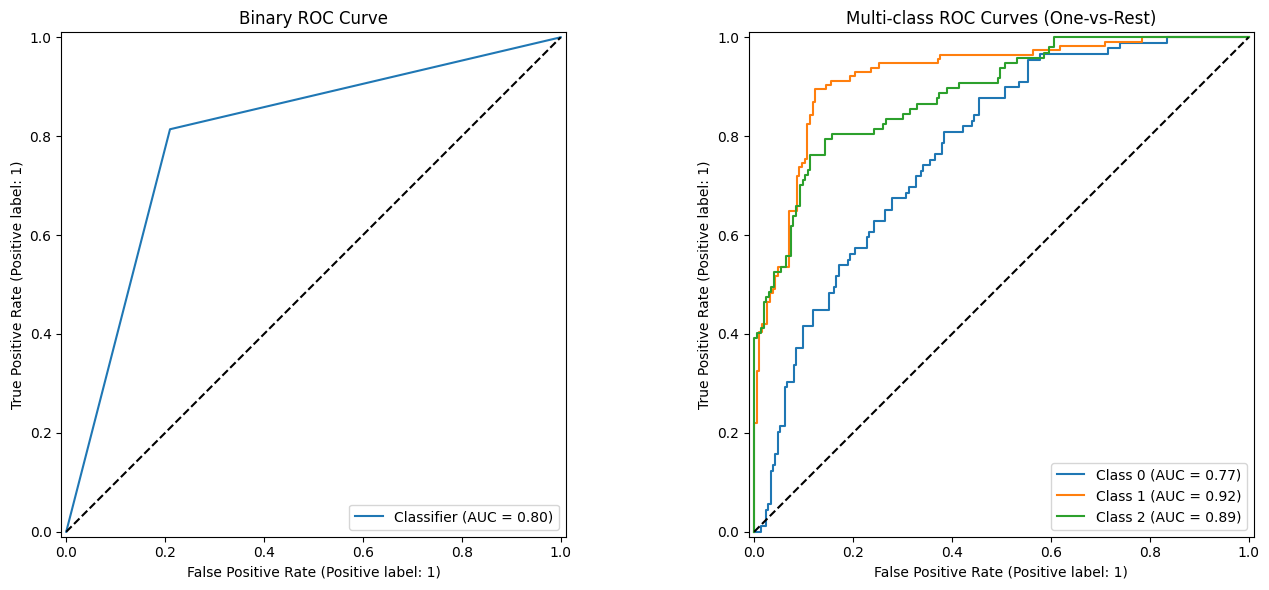

In [24]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Binary ROC Curve ---
RocCurveDisplay.from_predictions(y_true_bin, y_pred_bin, ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--')
axes[0].set_title("Binary ROC Curve")

# --- Multi-class ROC Curves ---
for i in range(3):
    RocCurveDisplay.from_predictions(y_test_bin[:, i], y_score[:, i], name=f"Class {i}", ax=axes[1])
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("Multi-class ROC Curves (One-vs-Rest)")

plt.tight_layout()
plt.show()

### Precision Recall Curve - for Imbalanced Class data

PR Curve Basics
$$
Precision = \frac{TP}{TP+FP}
$$
$$
Recall (TPR) = \frac{TP}{TP+FN}
$$
- The curve plots Precision (y-axis) vs Recall (x-axis) at different thresholds.

#### Baseline = positive class prevalence (horizontal line at that precision when recall = 1).

#### "Average Precision (AP) is the summary metric, analogous to ROC AUC"

#### Binary Classification

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binary PR curve
precision_bin, recall_bin, thresholds_bin = precision_recall_curve(y_true_bin, y_pred_bin)
ap_bin = average_precision_score(y_true_bin, y_pred_bin)

print(f'precision : {precision_bin[:5]}')
print(f'recall    : {recall_bin[:5]}')
print(f'Average Precision Score (AP) : {ap_bin:.4f}')

precision : [0.414     0.7326087 1.       ]
recall    : [1.         0.81400966 0.        ]
Average Precision Score (AP) : 0.6734


#### Multi-class classification

In [26]:
from sklearn.metrics import PrecisionRecallDisplay

# Binarize labels for PR computation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Compute PR curve for one class (say class 1)
precision, recall, thresholds = precision_recall_curve(y_test_bin[:, 1], y_score[:, 1])
ap_class1 = average_precision_score(y_test_bin[:, 1], y_score[:, 1])

print(f"precision : {precision[:5]}")
print(f"recall    : {recall[:5]}")
print(f"Average Precision Score (class 1): {ap_class1:.4f}")

# Multi-class Average Precision (macro)
ap_multi = average_precision_score(y_test_bin, y_score, average='macro')
print(f"Average Precision Score (multi-class, macro): {ap_multi:.4f}")

precision : [0.38       0.3812709  0.38255034 0.38383838 0.38513514]
recall    : [1. 1. 1. 1. 1.]
Average Precision Score (class 1): 0.8794
Average Precision Score (multi-class, macro): 0.7448


#### Interpretation

- Baseline (horizontal line): random guessing, equal to positive class prevalence.
- Curve above baseline: better-than-random performance.
- Closer to top-right corner: better classifier (high precision and recall).

**Average Precision (AP) :**
- AP = 1 → Perfect classifier
- AP = prevalence → Random guessing
- Higher AP means better overall performance.

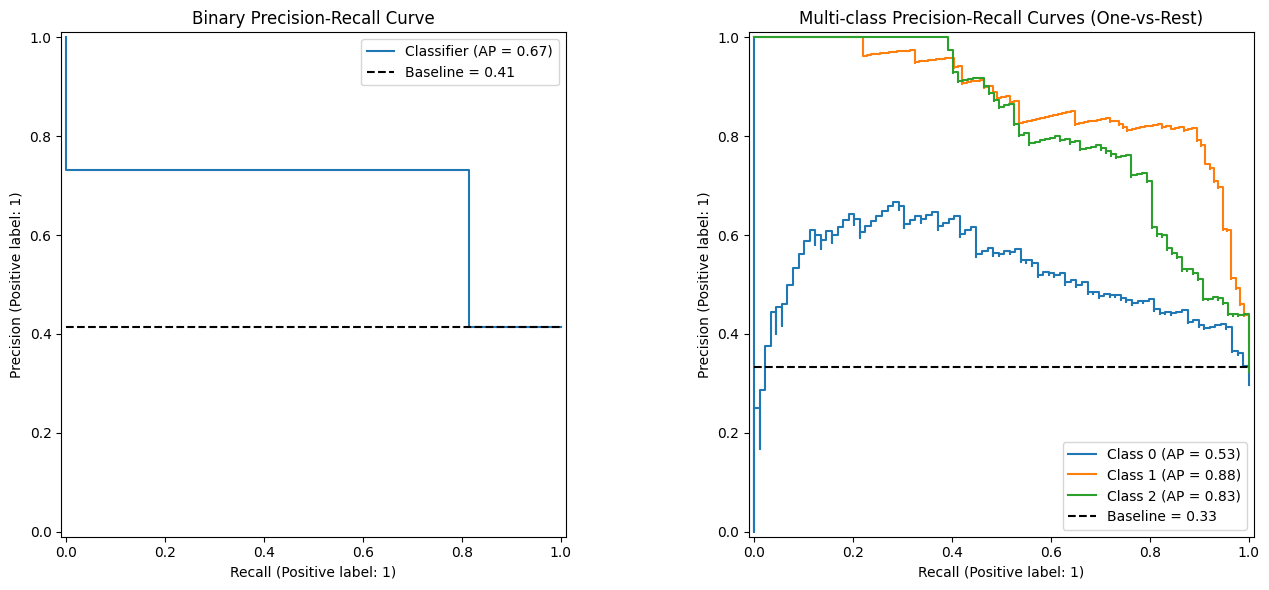

In [27]:
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Binary PR Curve ---
PrecisionRecallDisplay.from_predictions(y_true_bin, y_pred_bin, ax=axes[0])
baseline_bin = y_true_bin.mean()
axes[0].hlines(baseline_bin, 0, 1, colors='k', linestyles='--', label=f"Baseline = {baseline_bin:.2f}")
axes[0].set_title("Binary Precision-Recall Curve")
axes[0].legend()

# --- Multi-class PR Curves ---
for i in range(3):
    PrecisionRecallDisplay.from_predictions(y_test_bin[:, i], y_score[:, i], name=f"Class {i}", ax=axes[1])
baseline_multi = y_test_bin.mean()
axes[1].hlines(baseline_multi, 0, 1, colors='k', linestyles='--', label=f"Baseline = {baseline_multi:.2f}")
axes[1].set_title("Multi-class Precision-Recall Curves (One-vs-Rest)")
axes[1].legend()

plt.tight_layout()
plt.show()